# 05 - Model Comparison: Tweedie GLM vs Gradient Boosting

## Purpose

The purpose of this notebook is to compare the predictive performance of the Tweedie GLM model and the Gradient Boosting model. Using a consistent preprocessing pipeline and evaluation framework, the models are assessed using standard regression metrics to highlight differences in accuracy, interpretability and suitability for commercial property fire-peril loss cost modelling.

## Methodology

This notebook compares a Tweedie GLM and a Gradient Boosting regression model for predicting commercial property fire-peril loss cost. Both models are evaluated using the same training-test split, preprocessing pipeline and evaluation metrics to ensure a fair comparison.

Model performance is assessed on a hold-out test set using RMSE, MAE and R^2. The results are summarized in tabular form to highlight the differences in predictive accuracy, stability and interpretability between classic actuarial and machine-learning approaches.

In [1]:
# ======================================================
# CIND820 - Keystone Project
# Model Comparison: Fire Peril Loss Cost (Liberty Mutual Insurance)
# Author: Debra Allen 
# ======================================================

# Call Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

In [2]:
# =======================================================
# Data Preparation for Modeling: Fire Peril Loss Cost
# =======================================================

# Import necessary libraries for data preparation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import TweedieRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Data Loading

In [3]:
# ======================================================
# Load the dataset and display basic information
# ======================================================

# Use a smaller sample for modeling to avoid memory issues
def find_repo_root(start_path=None, marker_files=("'git", "README.md")):
    """
    Walk up the directory to find the repository root.
    The root is identified by the presence of marker files (e.g., .git, README.md).
    """
    if start_path is None:
        start_path = Path.cwd()
    
    start_path = start_path.resolve()

    for parent in [start_path] + list(start_path.parents):
        for marker in marker_files:
            if (parent / marker).exists():
                return parent
    raise FileNotFoundError("Could not find repo root. Run notebook from inside the repo.")

REPO_ROOT = find_repo_root()
SAMPLE_PATH = REPO_ROOT / "data" / "liberty_train_subset.csv"
print("Repo Root:", REPO_ROOT)
print("Data Path:", SAMPLE_PATH)

# Load a smaller sample of the dataset for modeling
model_data = pd.read_csv(SAMPLE_PATH, low_memory=False)

# Display basic information about the dataset
model_data.info()

Repo Root: C:\Users\uni_f\Downloads\LaTex\TMU-CIND820
Data Path: C:\Users\uni_f\Downloads\LaTex\TMU-CIND820\data\liberty_train_subset.csv
<class 'pandas.DataFrame'>
RangeIndex: 113015 entries, 0 to 113014
Columns: 302 entries, id to weatherVar236
dtypes: float64(291), int64(1), str(10)
memory usage: 260.4 MB


## Data Preparation

In [4]:
# ======================================================
# Prepare the dataset for modeling
# ======================================================

# Convert categorical variables to string type (if any)
for col in model_data.select_dtypes(include=["object"]).columns:
    model_data[col] = model_data[col].astype(str)

# Define the target variable and predictor variables
target = "target"
X = model_data.drop(columns=[target])
y = model_data[target]

C:\Users\uni_f\AppData\Local\Temp\ipykernel_25184\2822705644.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in model_data.select_dtypes(include=["object"]).columns:


In [5]:
# ======================================================
# Identify Variable Types
# ======================================================

# Identify categorical and numerical variables
categorical_vars = X.select_dtypes(include=["object"]).columns.tolist()
numerical_vars = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Display variable types
print("Categorical Variables:", categorical_vars)
print("Numerical Variables:", numerical_vars)

# Display number of numerical and categorical variables
print("\nNumber of Categorical Variables:", len(categorical_vars))
print("Number of Numerical Variables:", len(numerical_vars))

Categorical Variables: ['var1', 'var2', 'var3', 'var4', 'var5', 'var6', 'var7', 'var8', 'var9', 'dummy']
Numerical Variables: ['id', 'var10', 'var11', 'var12', 'var13', 'var14', 'var15', 'var16', 'var17', 'crimeVar1', 'crimeVar2', 'crimeVar3', 'crimeVar4', 'crimeVar5', 'crimeVar6', 'crimeVar7', 'crimeVar8', 'crimeVar9', 'geodemVar1', 'geodemVar2', 'geodemVar3', 'geodemVar4', 'geodemVar5', 'geodemVar6', 'geodemVar7', 'geodemVar8', 'geodemVar9', 'geodemVar10', 'geodemVar11', 'geodemVar12', 'geodemVar13', 'geodemVar14', 'geodemVar15', 'geodemVar16', 'geodemVar17', 'geodemVar18', 'geodemVar19', 'geodemVar20', 'geodemVar21', 'geodemVar22', 'geodemVar23', 'geodemVar24', 'geodemVar25', 'geodemVar26', 'geodemVar27', 'geodemVar28', 'geodemVar29', 'geodemVar30', 'geodemVar31', 'geodemVar32', 'geodemVar33', 'geodemVar34', 'geodemVar35', 'geodemVar36', 'geodemVar37', 'weatherVar1', 'weatherVar2', 'weatherVar3', 'weatherVar4', 'weatherVar5', 'weatherVar6', 'weatherVar7', 'weatherVar8', 'weatherVar9

C:\Users\uni_f\AppData\Local\Temp\ipykernel_25184\2312351895.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_vars = X.select_dtypes(include=["object"]).columns.tolist()


## Preprocessing the Data

In [6]:
# ======================================================
# Preprocess the dataset
# ======================================================

# Numerical pipeline: impute missing values with median and standardize
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: impute missing values with most frequent and one-hot encode
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine numerical and categorical pipelines into a ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_vars),
    ('cat', categorical_pipeline, categorical_vars)
],
remainder='drop',
n_jobs=-1
)

In [7]:
# =======================================================
# Train-Test Split
# =======================================================

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTraining observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])


Training observations: 90412
Testing observations: 22603


## Define Models

In [8]:
# ======================================================
# Define Models
# ======================================================

# Define the Tweedie GLM model
glm_model = TweedieRegressor(
    power=1.5,  # Tweedie distribution with power between 1 and 2 for insurance claims
    alpha=0.1,  # Regularization strength
    link='log',
    max_iter=1000
)

# Define the Gradient Boosting Regressor model
gbm_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

## Create Pipelines for Both Models

In [9]:
# ======================================================
# Build Pipelines for Both Models
# ======================================================

# Pipeline for Tweedie GLM model
glm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', glm_model)
])

# Pipeline for Gradient Boosting Regressor model
gbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', gbm_model)
])

## Fit Models to Training Data

In [10]:
# ======================================================
# Fit the models on the training data
# ======================================================

glm_pipeline.fit(X_train, y_train)
gbm_pipeline.fit(X_train, y_train)

print("Tweedie GLM fitted successfully.")
print("Gradient Boosting Model fitted successfully.")

Tweedie GLM fitted successfully.
Gradient Boosting Model fitted successfully.


## Model Evaluation

In [11]:
# ======================================================
# Evaluate the models on the testing data
# ======================================================

# Predictions
def predict_and_evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return{
        'RMSE': mean_squared_error(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }

glm_metrics = predict_and_evaluate(glm_pipeline, X_test, y_test)
gbm_metrics = predict_and_evaluate(gbm_pipeline, X_test, y_test)

y_pred_glm = glm_pipeline.predict(X_test)
y_pred_gbm = gbm_pipeline.predict(X_test)

## Weighted GINI

In [12]:
# ======================================================
# Calculate Weighted GINI
# ======================================================

def weighted_gini(y_true, y_pred, sample_weight=None):
    """ Compute the weighted GINI coefficient for regression predictions.
    """
    if sample_weight is None:
        sample_weight = np.ones_like(y_true)
    
    # Sort by predicted values
    sorted_indices = np.argsort(y_pred)
    y_true = y_true[sorted_indices]
    y_pred = y_pred[sorted_indices]
    sample_weight = sample_weight[sorted_indices]
    
    # Cumulative sums
    cum_weight = np.cumsum(sample_weight)
    cum_loss = np.cumsum(y_true * sample_weight)
    
    # Total sums
    gini = np.sum(
        cum_loss[:-1] * sample_weight[1:] - 
        cum_loss[1:] * sample_weight[:-1]        
    )
    return gini / (cum_loss[-1] * cum_weight[-1])

# Calculate weighted GINI for both models
gini_glm = weighted_gini(y_test.values, y_pred_glm)
gini_gbm = weighted_gini(y_test.values, y_pred_gbm)

print("Tweedie GLM Gini: ", f"{gini_glm:.9f}", gini_glm)
print("Gradient Boosting Gini: ", f"{gini_gbm:.9f}", gini_gbm)

Tweedie GLM Gini:  -0.000044242 -4.424191479007212e-05
Gradient Boosting Gini:  -0.000044242 -4.424191479007211e-05


## Model Comparison

In [13]:
# ======================================================
# Create Comparison Table of Model Performance
# ======================================================

results = pd.DataFrame.from_dict(
    {
        'GLM': glm_metrics,
        'GBM': gbm_metrics
    },
    orient='index'
)

print("\nModel Performance Comparison:")
print(results)

# Create a more visually appealing comparison table
comparison_table = pd.DataFrame.from_dict(
    {
        'Tweedie GLM': glm_metrics,
        'Gradient Boosting': gbm_metrics
    },
    orient='index'
)

print("\nModel Performance Comparison:")
comparison_table


Model Performance Comparison:
         RMSE       MAE        R2
GLM  0.062604  0.014360 -0.000149
GBM  0.064260  0.015564 -0.026604

Model Performance Comparison:


,RMSE,MAE,R2
Tweedie GLM,0.062604,0.014360,-0.000149
Gradient Boosting,0.064260,0.015564,-0.026604


## Model Comparison Visualization

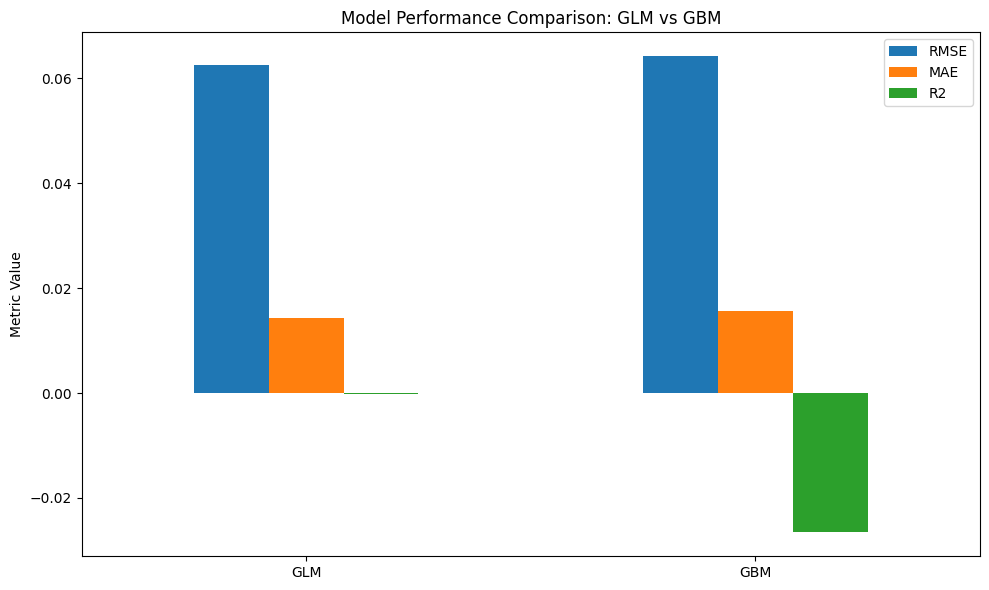

In [14]:
# ======================================================
# Visualize the performance comparison
# ======================================================

ax = results.plot(kind='bar', figsize=(10, 6), rot=0)
ax.set_title('Model Performance Comparison: GLM vs GBM')
ax.set_ylabel('Metric Value')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Model Comparison Summary

The Comparison Table compares the predictive performance of Tweedie GLM and a Gradient Boosting model. The GLM provides a stable and interpretable baseline suitable for insurance loss cost modelling. The Gradient Boosting model offers greater flexibility through non-linear interactions. In this initial analysis, neither model substantially outperforms a mean-based benchmark. This reflects the extreme sparsity and weak signal inherent in the fire-peril loss cost data.